In [10]:
import pandas as pd
import argparse
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
annot_test = pd.read_csv("/home/harsh/Documents/fau/thesis/thesis-codebase/data/vindr_cxr/annotations/annotations_test.csv")

In [3]:
annot_train = pd.read_csv("/home/harsh/Documents/fau/thesis/thesis-codebase/data/vindr_cxr/annotations/annotations_train.csv")
annot_train.head()

,image_id,rad_id,class_name,x_min,y_min,x_max,y_max
0,000434271f63a053c4128a0ba6352c7f,R2,No finding,NaN,NaN,NaN,NaN
1,000434271f63a053c4128a0ba6352c7f,R3,No finding,NaN,NaN,NaN,NaN
2,000434271f63a053c4128a0ba6352c7f,R6,No finding,NaN,NaN,NaN,NaN
3,00053190460d56c53cc3e57321387478,R11,No finding,NaN,NaN,NaN,NaN
4,00053190460d56c53cc3e57321387478,R2,No finding,NaN,NaN,NaN,NaN


In [4]:
annot_train[annot_train.image_id == '000434271f63a053c4128a0ba6352c7f']

,image_id,rad_id,class_name,x_min,y_min,x_max,y_max
0,000434271f63a053c4128a0ba6352c7f,R2,No finding,NaN,NaN,NaN,NaN
1,000434271f63a053c4128a0ba6352c7f,R3,No finding,NaN,NaN,NaN,NaN
2,000434271f63a053c4128a0ba6352c7f,R6,No finding,NaN,NaN,NaN,NaN


In [47]:
annot_train

,image_id,rad_id,class_name,x_min,y_min,x_max,y_max
0,000434271f63a053c4128a0ba6352c7f,R2,No finding,NaN,NaN,NaN,NaN
1,000434271f63a053c4128a0ba6352c7f,R3,No finding,NaN,NaN,NaN,NaN
2,000434271f63a053c4128a0ba6352c7f,R6,No finding,NaN,NaN,NaN,NaN
3,00053190460d56c53cc3e57321387478,R11,No finding,NaN,NaN,NaN,NaN
4,00053190460d56c53cc3e57321387478,R2,No finding,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
69047,fff0f82159f9083f3dd1f8967fc54f6a,R8,No finding,NaN,NaN,NaN,NaN
69048,fff0f82159f9083f3dd1f8967fc54f6a,R9,No finding,NaN,NaN,NaN,NaN
69049,fff2025e3c1d6970a8a6ee0404ac6940,R1,No finding,NaN,NaN,NaN,NaN
69050,fff2025e3c1d6970a8a6ee0404ac6940,R2,No finding,NaN,NaN,NaN,NaN


In [49]:
annot_train[annot_train.image_id == "0005e8e3701dfb1dd93d53e2ff537b6e"]

,image_id,rad_id,class_name,x_min,y_min,x_max,y_max
6,0005e8e3701dfb1dd93d53e2ff537b6e,R10,Infiltration,900.956970,587.809021,1205.359985,888.710999
7,0005e8e3701dfb1dd93d53e2ff537b6e,R10,Lung Opacity,900.956970,587.809021,1205.359985,888.710999
8,0005e8e3701dfb1dd93d53e2ff537b6e,R8,Consolidation,932.471985,567.778992,1197.770020,896.408997
9,0005e8e3701dfb1dd93d53e2ff537b6e,R8,Nodule/Mass,932.471985,567.778992,1197.770020,896.408997
10,0005e8e3701dfb1dd93d53e2ff537b6e,R9,Lung Opacity,905.224976,583.223999,1203.270020,890.148010


In [50]:
annot_train[annot_train.class_name == "Pleural thickening"]


,image_id,rad_id,class_name,x_min,y_min,x_max,y_max
15,0007d316f756b3fa0baea2ff514ce945,R10,Pleural thickening,818.666016,677.098022,987.669983,939.344971
18,0007d316f756b3fa0baea2ff514ce945,R8,Pleural thickening,621.364990,673.406006,1025.859985,851.734009
19,0007d316f756b3fa0baea2ff514ce945,R9,Pleural thickening,790.047974,634.903015,1047.839966,725.039001
38,000d68e42b71d3eac10ccc077aba07c1,R9,Pleural thickening,469.346008,303.131989,781.734985,369.774994
40,000d68e42b71d3eac10ccc077aba07c1,R9,Pleural thickening,1184.920044,246.485992,1586.640015,327.946991
...,...,...,...,...,...,...,...
68985,ff924bcbd38f123aec723aa7040d7e43,R10,Pleural thickening,1875.180054,2243.419922,2067.979980,2475.810059
68990,ff924bcbd38f123aec723aa7040d7e43,R8,Pleural thickening,1860.380005,2239.719971,2057.090088,2441.100098
68992,ff924bcbd38f123aec723aa7040d7e43,R8,Pleural thickening,242.240997,2129.649902,504.515015,2382.560059
68998,ff924bcbd38f123aec723aa7040d7e43,R9,Pleural thickening,257.493988,2161.419922,389.139008,2305.310059


In [3]:
annot_test.head()

,image_id,class_name,x_min,y_min,x_max,y_max
0,e0dc2e79105ad93532484e956ef8a71a,Calcification,1221.560976,661.580417,1343.298780,783.318222
1,e0dc2e79105ad93532484e956ef8a71a,Cardiomegaly,638.695122,1310.848710,1800.737805,1937.982856
2,e0dc2e79105ad93532484e956ef8a71a,ILD,1693.756098,1392.007246,1929.853659,1941.671881
3,e0dc2e79105ad93532484e956ef8a71a,Pneumothorax,399.924053,145.803282,1016.600328,510.138208
4,e0dc2e79105ad93532484e956ef8a71a,Pneumothorax,334.300846,493.762382,453.145487,744.509170


In [4]:
annot_test.shape

(4748, 6)

In [6]:
annot_test.image_id.value_counts()

image_id
ab9dedb9ff4cd9e80dca74505b599105    11
daac34be8b6ca54b0ab1be81733c0d34    11
7858eba2f50d6d515f3ccbbbe9020fa4    11
5118cbe9894006f58312565294e85556    10
e1c35c4312a8aa97233d3b88fb07b033    10
                                    ..
60485f64a1de6c652639c3ab84fcd12f     1
8fc6580091f8d24be3dbd700d4630833     1
c5026a45c2acc85937d1f13c2638f97c     1
c84c9afed6d26c87c30b76ae29ebd290     1
d09ec8573f5c237e56bbeae80f877f18     1
Name: count, Length: 3000, dtype: int64

In [7]:
annot_test[annot_test.image_id == "ab9dedb9ff4cd9e80dca74505b599105"]

,image_id,class_name,x_min,y_min,x_max,y_max
2418,ab9dedb9ff4cd9e80dca74505b599105,Pleural thickening,1135.823714,331.361501,1387.619522,419.490034
2419,ab9dedb9ff4cd9e80dca74505b599105,Pulmonary fibrosis,1477.998645,920.401521,1657.949286,1120.072781
2420,ab9dedb9ff4cd9e80dca74505b599105,Pulmonary fibrosis,1512.149941,1447.780502,1743.376779,1700.864604
2421,ab9dedb9ff4cd9e80dca74505b599105,Pulmonary fibrosis,1441.795000,1197.359484,1733.943880,1444.379676
2422,ab9dedb9ff4cd9e80dca74505b599105,Pulmonary fibrosis,1607.202607,1714.024121,1762.454074,1813.151819
2423,ab9dedb9ff4cd9e80dca74505b599105,Pleural thickening,279.959131,1768.125387,398.180755,1955.966412
2424,ab9dedb9ff4cd9e80dca74505b599105,Pulmonary fibrosis,574.464191,434.711039,813.815767,563.931522
2425,ab9dedb9ff4cd9e80dca74505b599105,Nodule/Mass,462.581164,508.914228,691.484736,709.015364
2426,ab9dedb9ff4cd9e80dca74505b599105,Pulmonary fibrosis,424.546648,748.270553,546.499389,889.735732
2427,ab9dedb9ff4cd9e80dca74505b599105,Pulmonary fibrosis,323.864440,1455.483466,415.222231,1579.358437


In [13]:
annot_test[annot_test.image_id == "ab9dedb9ff4cd9e80dca74505b599105"].class_name.unique()

array(['Pleural thickening', 'Pulmonary fibrosis', 'Nodule/Mass'],
      dtype=object)

In [6]:
img_lbl_test = pd.read_csv("/home/harsh/Documents/fau/thesis/thesis-codebase/data/vindr_cxr/annotations/image_labels_test.csv")

In [9]:
img_lbl_test.head()

,image_id,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Clavicle fracture,Consolidation,Edema,Emphysema,Enlarged PA,...,Pneumothorax,Pulmonary fibrosis,Rib fracture,Other lesion,COPD,Lung tumor,Pneumonia,Tuberculosis,Other disease,No finding
0,e0dc2e79105ad93532484e956ef8a71a,0,1,1,1,0,0,0,0,0,...,1,0,0,0,0,0,1,0,1,0
1,0aed23e64ebdea798486056b4f174424,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,aa15cfcfca7605465ca0513902738b95,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,665c4a6d2693dc0286d65ab479c9b169,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,42da2c134b53cb5594774d3d29faac59,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [9]:
img_lbl_test[img_lbl_test.image_id == "ab9dedb9ff4cd9e80dca74505b599105"].T

,879
image_id,ab9dedb9ff4cd9e80dca74505b599105
Aortic enlargement,0
Atelectasis,0
Calcification,0
Cardiomegaly,0
Clavicle fracture,0
Consolidation,0
Edema,0
Emphysema,0
Enlarged PA,0


In [12]:
images_root = "/home/harsh/Documents/fau/thesis/thesis-codebase/data/vindr_cxr"
train_meta = pd.read_csv(Path(images_root) / "train_meta.csv")

In [13]:
train_meta.head()

,image_id,dim0,dim1
0,4d390e07733ba06e5ff07412f09c0a92,3000,3000
1,289f69f6462af4933308c275d07060f0,3072,3072
2,68335ee73e67706aa59b8b55b54b11a4,2836,2336
3,7ecd6f67f649f26c05805c8359f9e528,2952,2744
4,2229148faa205e881cf0d932755c9e40,2880,2304


In [43]:
x, y = train_meta.loc[train_meta['image_id'] == '4d390e07733ba06e5ff07412f09c0a92', 'dim0'].values, train_meta.loc[train_meta['image_id'] == '4d390e07733ba06e5ff07412f09c0a92', 'dim1'].values

In [44]:
x, y

(array([3000]), array([3000]))

In [45]:
def load_meta(meta_csv):
    """
    Load VinDr meta CSV with columns: image_id, dim0, dim1
    Returns dict: image_id -> (orig_height, orig_width)
    """
    df = pd.read_csv(meta_csv)
    meta = {}
    for _, r in df.iterrows():
        image_id = r["image_id"]
        # dim0 = height, dim1 = width (typical numpy convention)
        orig_h = int(r["dim0"])
        orig_w = int(r["dim1"])
        meta[image_id] = (orig_h, orig_w)
    return meta

In [46]:
def visualize_vindr_boxes(
    image_id: str,
    images_root: str,
    annotations_csv: str,
    meta_csv: str,
    save_path: str = None,
):
    """
    Visualize a 256x256 VinDr PNG with its bounding boxes,
    scaling the original annotations using train_meta.csv.
    """
    # Load annotations
    df = pd.read_csv(annotations_csv)
    rows = df[df["image_id"] == image_id]
    if rows.empty:
        raise ValueError(f"No annotations found for image_id={image_id} in {annotations_csv}")

    # Load meta for original size
    meta = load_meta(meta_csv)
    if image_id not in meta:
        raise KeyError(f"image_id={image_id} not found in meta CSV {meta_csv}")
    orig_h, orig_w = meta[image_id]

    # Load 256x256 PNG
    img_path = Path(images_root) / f"{image_id}.png"
    if not img_path.exists():
        raise FileNotFoundError(f"PNG not found: {img_path}")
    img = Image.open(img_path).convert("RGB")
    w_png, h_png = img.size

    assert w_png == h_png == 256, f"Expected 256x256 PNG, got {w_png}x{h_png}"

    # Scaling factors from original -> 256x256
    scale_x = w_png / float(orig_w)
    scale_y = h_png / float(orig_h)

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(img, cmap="gray")
    ax.axis("off")

    for _, r in rows.iterrows():
        x_min_orig = r["x_min"]
        y_min_orig = r["y_min"]
        x_max_orig = r["x_max"]
        y_max_orig = r["y_max"]
        label = r.get("class_name", "")

        # Scale to PNG coordinates
        x_min = x_min_orig * scale_x
        y_min = y_min_orig * scale_y
        x_max = x_max_orig * scale_x
        y_max = y_max_orig * scale_y

        width = x_max - x_min
        height = y_max - y_min

        rect = patches.Rectangle(
            (x_min, y_min),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)
        if label:
            ax.text(
                x_min,
                max(y_min - 2, 0),
                label,
                fontsize=8,
                color="yellow",
                bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
            )

    plt.tight_layout()
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150)
        print(f"Saved visualization to {save_path}")
    else:
        plt.show()

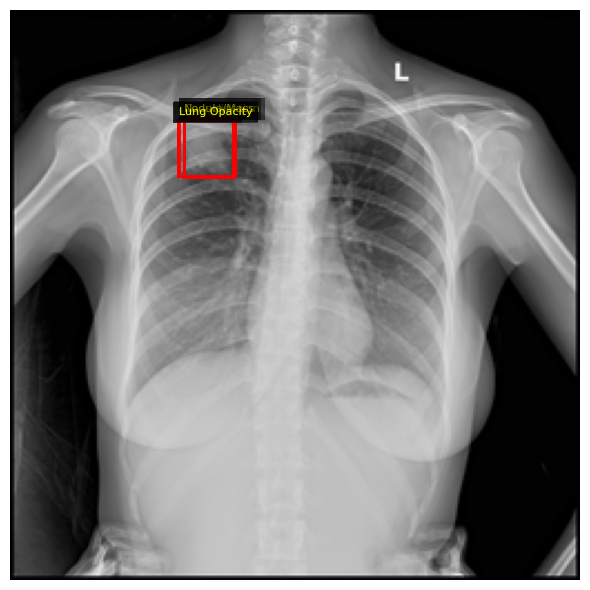

In [48]:
visualize_vindr_boxes(
    "0005e8e3701dfb1dd93d53e2ff537b6e",
    "/home/harsh/Documents/fau/thesis/thesis-codebase/data/vindr_cxr/train",
    "/home/harsh/Documents/fau/thesis/thesis-codebase/data/vindr_cxr/annotations/annotations_train.csv",
    "/home/harsh/Documents/fau/thesis/thesis-codebase/data/vindr_cxr/train_meta.csv",
)

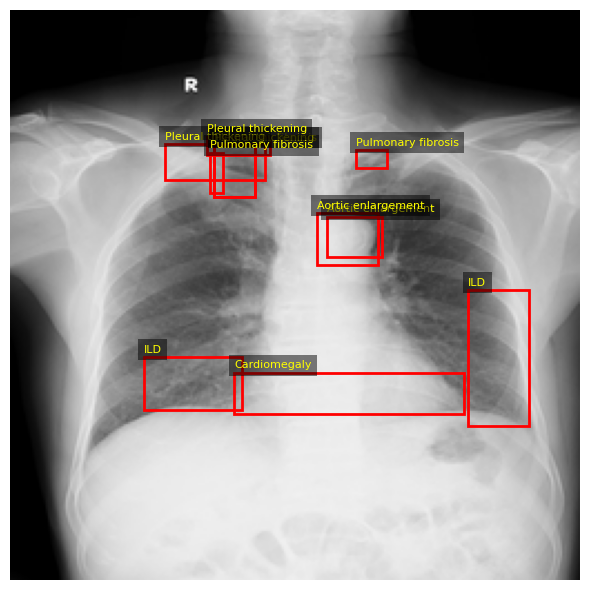

In [51]:
visualize_vindr_boxes(
    "0007d316f756b3fa0baea2ff514ce945",
    "/home/harsh/Documents/fau/thesis/thesis-codebase/data/vindr_cxr/train",
    "/home/harsh/Documents/fau/thesis/thesis-codebase/data/vindr_cxr/annotations/annotations_train.csv",
    "/home/harsh/Documents/fau/thesis/thesis-codebase/data/vindr_cxr/train_meta.csv",
)

In [53]:
img_lbl_test.columns[1:].values

array(['Aortic enlargement', 'Atelectasis', 'Calcification',
       'Cardiomegaly', 'Clavicle fracture', 'Consolidation', 'Edema',
       'Emphysema', 'Enlarged PA', 'ILD', 'Infiltration', 'Lung Opacity',
       'Lung cavity', 'Lung cyst', 'Mediastinal shift', 'Nodule/Mass',
       'Pleural effusion', 'Pleural thickening', 'Pneumothorax',
       'Pulmonary fibrosis', 'Rib fracture', 'Other lesion', 'COPD',
       'Lung tumor', 'Pneumonia', 'Tuberculosis', 'Other disease',
       'No finding'], dtype=object)